[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/00_simulation.ipynb)

# 00 — BandTilt Simulation

## 1. Overview

This notebook builds the synthetic network **BandTilt** is evaluated on: a multi-band antenna tilt
coordination study for coverage-efficient 5G/6G radio access networks. It combines a time-varying UE
population, Sionna-RT ray tracing and the project's KPI and objective definitions, and reports every
measure at the committed (baseline) tilt configuration.

**Inputs.** `configs/simulation.yaml`, `configs/kpi.yaml`.
**Outputs.** `data/external/` (UE positions, scenario manifest), `data/interim/radio_map.npz`, and
tables and figures under `reports/`.
**Requirements.** A CUDA GPU for Sionna-RT. The shell equivalent is `task simulation`.
Optimization and the baseline-versus-optimized comparison live in notebooks 03a, 03b and 04.

In [1]:
# Environment: locally, move to the project root; on Colab, clone the repository
# and install what Colab lacks. Extra Hydra overrides come from BAND_TILT_OVERRIDES.
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
COLAB_PACKAGES = [("hydra", "hydra-core"), ("sionna.rt", "sionna-rt")]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    root = Path("/content/band-tilt")
    if not root.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(root)], check=True)
    missing = [pip for module, pip in COLAB_PACKAGES if importlib.util.find_spec(module) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
sys.path.insert(0, str(root))
CONFIG_OVERRIDES = os.environ.get("BAND_TILT_OVERRIDES", "").split()

In [2]:
%load_ext autoreload
%autoreload 2

import json
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.config import load_config
from src.evaluation.export import save_table
from src.utils.plotting import label, save_fig, setup_plotting
from src.utils.seed import set_seed

cfg = load_config(overrides=CONFIG_OVERRIDES)
set_seed(cfg.seed)
setup_plotting()
save_fig = partial(save_fig, in_colab=IN_COLAB, directory=Path("reports/figures/00_simulation"))
save_table = partial(save_table, in_colab=IN_COLAB, directory=Path("reports/tables/00_simulation"))
pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 40)


def property_table(values, name):
    """A two-column Property/Value table, saved under ``name``."""
    table = pd.DataFrame({"Value": values}).rename_axis("Property").reset_index()
    save_table(table, name)
    return table

## 2. Simulation Objectives

The simulation:

* draws a spatially and temporally varying UE population over the open ground of a 3D city scene;
* ray-traces the received signal power of every cell on every frequency band over a measurement grid;
* assigns each UE a serving cell-band under band preference and PRB limits;
* measures coverage, co-band overlap, service and load at the committed tilts.

The search maximises one objective (ADR 0006, `src/optim/objective.py`):

$$
J = J_{\mathrm{radio}}^{\gamma}\; J_{\mathrm{load}}^{1-\gamma},
$$

where $J_{\mathrm{radio}}$ rewards coverage and penalises every co-band overlapping neighbour, and
$J_{\mathrm{load}}$ penalises the upper tail of PRB utilisation. Five KPIs are reported beside it and
never weighted into it: coverage hole rate, co-band overlap rate, served UE ratio, weak coverage rate
and cell-edge RSRP (Section 8).

## 3. Simulation Scenario

The scenario fixes the city, the cell layout and the user population once, so that every later KPI
change is caused by tilt alone.

In [3]:
from src.simulation import scenario, transmitter

ue_file, manifest_file = scenario.generate(cfg)
manifest = json.loads(Path(manifest_file).read_text(encoding="utf-8"))
ue = pd.read_csv(ue_file)
cells = transmitter.load(cfg)
bands = [str(entry.name) for entry in cfg.simulation.radio_map.bands]
nodes = pd.DataFrame({"x": [cell.x for cell in cells], "y": [cell.y for cell in cells]})
grid = manifest["grid"]

jitc_llvm_init(): LLVM API initialization failed ..


scenario: scn_61e174bef723f9c4
grid:     310 x 326 tiles, 97910 eligible
hotspots: 4
time:     672 intervals of 900 s, 10-20 UEs each
demand:   hotspots hold 78% to 95% of the population across intervals
ue:       10066 rows at z=1.5 m
densest decile holds 100.0% of UEs
csv:      data\external\ue_positions.csv
manifest: data\external\scenario.json


### 3.1 Study Area

Coordinates are the scene's local Cartesian frame in metres. The grid spans the scene's bounding box;
UEs and masts may only stand on open ground.

In [4]:
display(
    property_table(
        {
            "Environment": "Urban city scene (Sionna-RT, merged building meshes)",
            "3D scene source": str(cfg.simulation.scene.name),
            "Simulation area [m]": f"{grid['n_cols'] * grid['tile_size_m']:.0f} x "
            f"{grid['n_rows'] * grid['tile_size_m']:.0f}",
            "Grid resolution [m]": grid["tile_size_m"],
            "Grid [tiles]": f"{grid['n_rows']} x {grid['n_cols']}",
            "Evaluation points (tiles)": grid["n_rows"] * grid["n_cols"],
            "Tiles holding at least one UE": ue[["tile_row", "tile_col"]]
            .drop_duplicates()
            .shape[0],
            "Coordinate system": "Local Cartesian, metres (scene frame)",
            "Scenario ID": manifest["scenario_id"],
        },
        "study_area",
    )
)

,Property,Value
0,Environment,"Urban city scene (Sionna-RT, merged building m..."
1,3D scene source,data/external/scene/scene.xml
2,Simulation area [m],6200 x 6520
3,Grid resolution [m],20.0
4,Grid [tiles],326 x 310
5,Evaluation points (tiles),101060
6,Tiles holding at least one UE,2632
7,Coordinate system,"Local Cartesian, metres (scene frame)"
8,Scenario ID,scn_61e174bef723f9c4


### 3.2 Network Configuration

Four nodes stand on the corners and centroid of an equilateral triangle. Every node carries three
sectors, rotated by the configured azimuth offset, and every sector serves every band. Each
(cell, band) pair has its own tilt: the decision variable of the study.

In [5]:
layout_cfg = cfg.simulation.transmitters.layout
tx_array = cfg.simulation.antenna.transmitter
tilts = [cell.tilt_for(band) for cell in cells for band in bands]
display(
    property_table(
        {
            "Number of sites (nodes)": len({(cell.x, cell.y) for cell in cells}),
            "Sectors per site": int(layout_cfg.cells_per_node),
            "Number of cells": len(cells),
            "Cell-band pairs (decision variables)": len(cells) * len(bands),
            "Frequency bands": ", ".join(label(band) for band in bands),
            "Azimuth offset [°]": float(layout_cfg.azimuth_offset_deg),
            "Reference-signal power per RE [dBm]": float(cfg.simulation.antenna.power_rs),
            "Antenna model": f"{tx_array.num_rows}x{tx_array.num_cols} planar array, "
            f"{tx_array.pattern} pattern, {tx_array.polarization} polarization",
            "Initial electrical tilt [°]": ", ".join(
                sorted({f"{tilt.baseline_deg:g}" for tilt in tilts})
            ),
            "Tilt bounds [°]": ", ".join(
                sorted({f"{tilt.bounds_deg[0]:g} to {tilt.bounds_deg[1]:g}" for tilt in tilts})
            ),
            "Base-station height [m]": ", ".join(sorted({f"{c.z:g}" for c in cells})),
        },
        "network_configuration",
    )
)


def tilt_text(tilt):
    """Current tilt with its allowed range, e.g. ``12 (0 to 15)``."""
    low, high = tilt.bounds_deg
    return f"{tilt.baseline_deg:g} ({low:g} to {high:g})"


layout = pd.DataFrame(
    [
        {
            "Node": cell.name.rsplit("c", 1)[0],
            "Cell": cell.name,
            "x [m]": cell.x,
            "y [m]": cell.y,
            "Antenna height [m]": cell.z,
            "Azimuth [°]": cell.azimuth_deg,
            **{
                f"{label(band)} tilt [°] (allowed range)": tilt_text(cell.tilt_for(band))
                for band in bands
            },
        }
        for cell in cells
    ]
)
save_table(layout, "node_layout")
display(layout)

carriers = pd.DataFrame(
    [
        {
            "Band": label(entry.name),
            "Carrier frequency [MHz]": float(entry.frequency) / 1e6,
            "Bandwidth [MHz]": float(entry.bandwidth) / 1e6,
            "PRB limit per cell": ", ".join(
                str(limit) for limit in sorted({cell.max_prb_for(entry.name) for cell in cells})
            ),
        }
        for entry in cfg.simulation.radio_map.bands
    ]
)
save_table(carriers, "frequency_bands")
carriers

,Property,Value
0,Number of sites (nodes),4
1,Sectors per site,3
2,Number of cells,12
3,Cell-band pairs (decision variables),36
4,Frequency bands,"2600 MHz, 1800 MHz, 700 MHz"
5,Azimuth offset [°],-45.0
6,Reference-signal power per RE [dBm],4.85
7,Antenna model,"8x8 planar array, tr38901 pattern, cross polar..."
8,Initial electrical tilt [°],12
9,Tilt bounds [°],0 to 15


,Node,Cell,x [m],y [m],Antenna height [m],Azimuth [°],2600 MHz tilt [°] (allowed range),1800 MHz tilt [°] (allowed range),700 MHz tilt [°] (allowed range)
0,n0,n0c0,29.20,1027.34,20.0,315.0,12 (0 to 15),12 (0 to 15),12 (0 to 15)
1,n0,n0c1,29.20,1027.34,20.0,75.0,12 (0 to 15),12 (0 to 15),12 (0 to 15)
2,n0,n0c2,29.20,1027.34,20.0,195.0,12 (0 to 15),12 (0 to 15),12 (0 to 15)
3,n1,n1c0,-858.62,-499.98,20.0,315.0,12 (0 to 15),12 (0 to 15),12 (0 to 15)
4,n1,n1c1,-858.62,-499.98,20.0,75.0,12 (0 to 15),12 (0 to 15),12 (0 to 15)
5,n1,n1c2,-858.62,-499.98,20.0,195.0,12 (0 to 15),12 (0 to 15),12 (0 to 15)
6,n2,n2c0,873.38,-499.98,20.0,315.0,12 (0 to 15),12 (0 to 15),12 (0 to 15)
7,n2,n2c1,873.38,-499.98,20.0,75.0,12 (0 to 15),12 (0 to 15),12 (0 to 15)
8,n2,n2c2,873.38,-499.98,20.0,195.0,12 (0 to 15),12 (0 to 15),12 (0 to 15)
9,n3,n3c0,7.38,0.00,20.0,315.0,12 (0 to 15),12 (0 to 15),12 (0 to 15)


,Band,Carrier frequency [MHz],Bandwidth [MHz],PRB limit per cell
0,2600 MHz,2600.0,40.0,216
1,1800 MHz,1800.0,20.0,106
2,700 MHz,700.0,10.0,52


### 3.3 UE Distribution

UE positions are drawn independently in every interval from a spatial mixture: a uniform open-ground
background plus Gaussian demand hotspots centred where building volume is high. The mixture masses and
the UE count vary over time with a diurnal profile and an AR(1) term. Every drawn UE is kept, including
UEs that no cell reaches.

In [6]:
time_cfg, density_cfg = cfg.simulation.time, cfg.simulation.density
low, high = cfg.simulation.ue.count_range
display(
    property_table(
        {
            "UEs per interval": f"{low} to {high}",
            "UE positions drawn (all intervals)": len(ue),
            "Simulation duration [days]": float(time_cfg.horizon_s) / 86400,
            "Sampling interval [min]": float(time_cfg.interval_s) / 60,
            "Time intervals": manifest["time"]["n_intervals"],
            "Mobility model": "Independent draw per interval (no trajectories)",
            "UE height [m]": float(cfg.simulation.ue.height_m),
            "Density model": f"Uniform background + {len(manifest['density']['hotspots'])} "
            f"Gaussian hotspots holding {float(density_cfg.hotspot_mass_fraction):.0%} of UEs",
        },
        "ue_distribution",
    )
)

,Property,Value
0,UEs per interval,10 to 20
1,UE positions drawn (all intervals),10066
2,Simulation duration [days],7.0
3,Sampling interval [min],15.0
4,Time intervals,672
5,Mobility model,Independent draw per interval (no trajectories)
6,UE height [m],1.5
7,Density model,Uniform background + 4 Gaussian hotspots holdi...


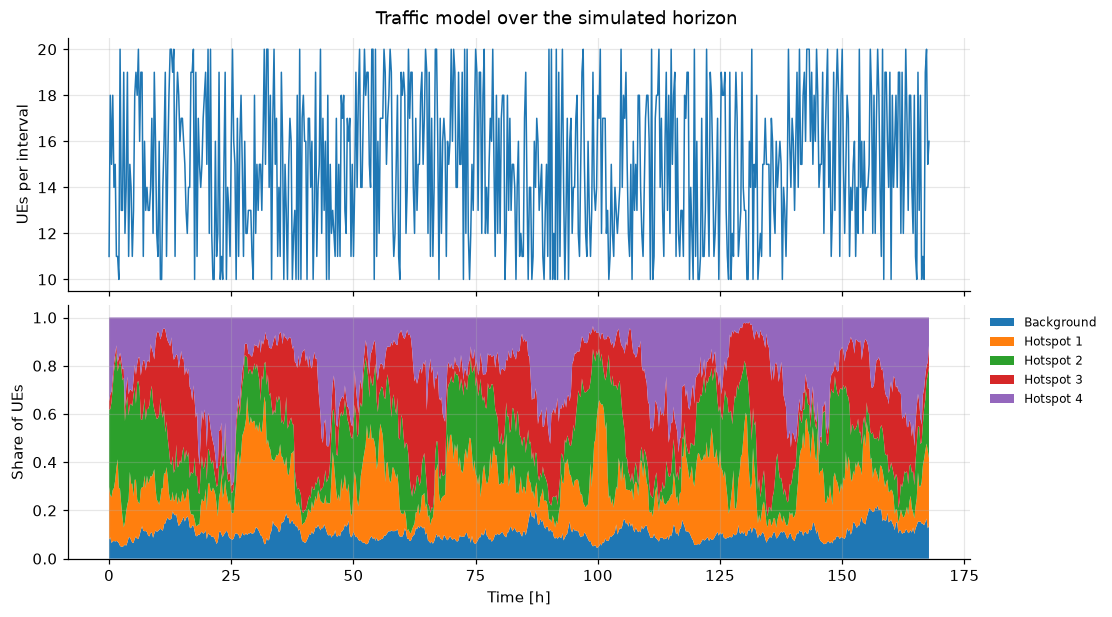

In [7]:
hours = np.asarray(manifest["time"]["t_s"]) / 3600.0
mass = np.asarray(manifest["time"]["component_mass"])

figure, axes = plt.subplots(2, 1, figsize=(10.0, 5.5), sharex=True, constrained_layout=True)
axes[0].plot(hours, manifest["time"]["count"], lw=1.0)
axes[0].set_ylabel("UEs per interval")
axes[1].stackplot(
    hours,
    mass.T,
    labels=["Background"] + [f"Hotspot {index + 1}" for index in range(mass.shape[1] - 1)],
)
axes[1].set(xlabel="Time [h]", ylabel="Share of UEs")
axes[1].legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8)
figure.suptitle("Traffic model over the simulated horizon")
save_fig(figure, "traffic_model")
plt.show()

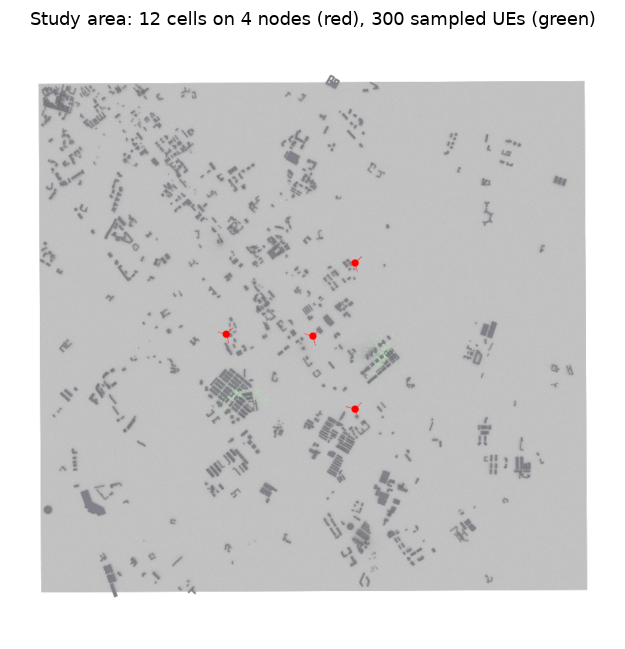

In [8]:
from sionna.rt import Receiver

from src.simulation import scene as scene_module

UE_RENDER_SAMPLE = 300

scene, bounds = scene_module.load(scene_module.SceneSpec.from_config(cfg))
transmitter.build(scene, cells, bands[0], float(cfg.simulation.antenna.power_rs))
sample = ue.sample(n=min(UE_RENDER_SAMPLE, len(ue)), random_state=cfg.seed)
for index, row in enumerate(sample.itertuples()):
    scene.add(Receiver(name=f"ue{index}", position=[row.x, row.y, row.z], display_radius=6.0))

figure = scene_module.render_top_down(
    scene,
    bounds,
    f"Study area: {len(cells)} cells on {len(nodes.drop_duplicates())} nodes (red), "
    f"{len(sample)} sampled UEs (green)",
    show_devices=True,
    show_orientations=True,
)
save_fig(figure, "study_area")
plt.show()
del scene

## 4. Radio Propagation Model

Radio propagation is simulated with **Sionna RT** over the 3D scene, one solve per band, with every
cell at its configured tilt. The radio-map solver records the mechanisms below.

In [9]:
rm = cfg.simulation.radio_map
rx_array = cfg.simulation.antenna.receiver
display(
    property_table(
        {
            "Maximum path depth": int(rm.max_depth),
            "Ray samples per transmitter": f"{int(rm.samples_per_tx):,}",
            "Line of sight": bool(rm.los),
            "Specular reflection": bool(rm.specular_reflection),
            "Diffuse reflection (scattering)": bool(rm.diffuse_reflection),
            "Refraction": bool(rm.refraction),
            "Diffraction": bool(rm.diffraction),
            "Edge diffraction": bool(rm.edge_diffraction),
            "Receiver antenna": f"{rx_array.num_rows}x{rx_array.num_cols} {rx_array.pattern}, "
            f"{rx_array.polarization} polarization",
            "Propagation materials": "Frequency-static (src/simulation/materials.py)",
            "Noise temperature [K]": float(rm.temperature),
        },
        "propagation_parameters",
    )
)

,Property,Value
0,Maximum path depth,8
1,Ray samples per transmitter,"10,000,000"
2,Line of sight,True
3,Specular reflection,True
4,Diffuse reflection (scattering),False
5,Refraction,True
6,Diffraction,False
7,Edge diffraction,False
8,Receiver antenna,"1x1 dipole, V polarization"
9,Propagation materials,Frequency-static (src/simulation/materials.py)


The solver's path gain is converted into reference-signal received power:

$$
P_{\mathrm{RX}}(g,c) = P_{\mathrm{TX}}(c) + G_{\mathrm{path}}(g,c) - L_{\mathrm{system}}(c),
$$

where $g$ is a grid tile, $c$ a cell-band pair, $P_{\mathrm{TX}}$ the per-resource-element
reference-signal power (`simulation.antenna.power_rs`), and $G_{\mathrm{path}}$ the ray-traced path
gain in dB including both antenna patterns. The implementation applies no additional system loss
($L_{\mathrm{system}} = 0$). A tile no ray reaches has no value (NaN) for that cell-band.

   b2600  tilt 12.0-12.0 deg     2.1s  tiles reached  82.0%  best server -234.1 to  -48.9 dBm


   b1800  tilt 12.0-12.0 deg     1.1s  tiles reached  81.8%  best server -234.6 to  -45.4 dBm


    b700  tilt 12.0-12.0 deg     1.1s  tiles reached  85.4%  best server -213.7 to  -37.7 dBm


radio map: data\interim\radio_map.npz  shape (3, 12, 326, 310) [band, tx, row, col]


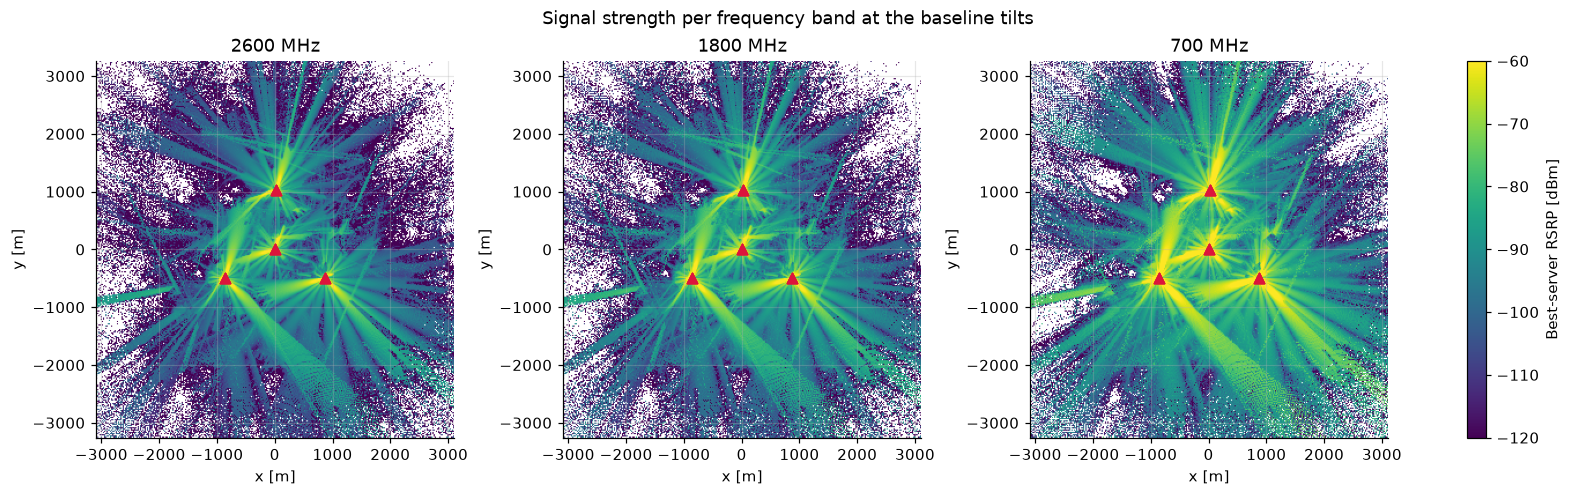

In [10]:
from src.evaluation import maps, plots
from src.kpi.capacity import max_rsrp
from src.simulation import radio

radio_map_file = radio.solve(cfg)
with np.load(radio_map_file, allow_pickle=False) as archive:
    radio_map = {key: archive[key] for key in archive.files}
rsrp = radio_map["rsrp_dbm"].astype(float)
sinr = radio_map["sinr_db"].astype(float)
best_per_band = {band: max_rsrp(rsrp[[index]]) for index, band in enumerate(bands)}

figure = plots.map_row(
    {label(band): best for band, best in best_per_band.items()},
    radio_map,
    colorbar_label="Best-server RSRP [dBm]",
    vmin=maps.RSRP_LIMITS[0],
    vmax=maps.RSRP_LIMITS[1],
    cells=nodes,
)
figure.suptitle("Signal strength per frequency band at the baseline tilts")
save_fig(figure, "rsrp_per_band")
plt.show()

In [11]:
reach = pd.DataFrame(
    [
        {
            "Band": label(band),
            "Tiles reached [%]": 100.0 * np.isfinite(best).mean(),
            "Median RSRP of reached tiles [dBm]": float(np.median(best[np.isfinite(best)])),
        }
        for band, best in best_per_band.items()
    ]
)
save_table(reach, "reach_per_band")
reach

,Band,Tiles reached [%],Median RSRP of reached tiles [dBm]
0,2600 MHz,81.9543,-103.0033
1,1800 MHz,81.7603,-98.8026
2,700 MHz,85.4067,-92.0202


## 5. UE Measurements

Earlier versions sampled the radio map at each UE and added receiver noise to build a synthetic MDT,
dropping UEs no cell reached. That step is removed. The KPIs read each UE's interval and grid tile
from `data/external/ue_positions.csv` and look the clean radio map up at that tile. **Every UE is
kept**: a UE on a tile with no path to any cell counts as not served.

Neither measurement noise, missing neighbour reports, reporting thresholds nor position uncertainty
is modelled.

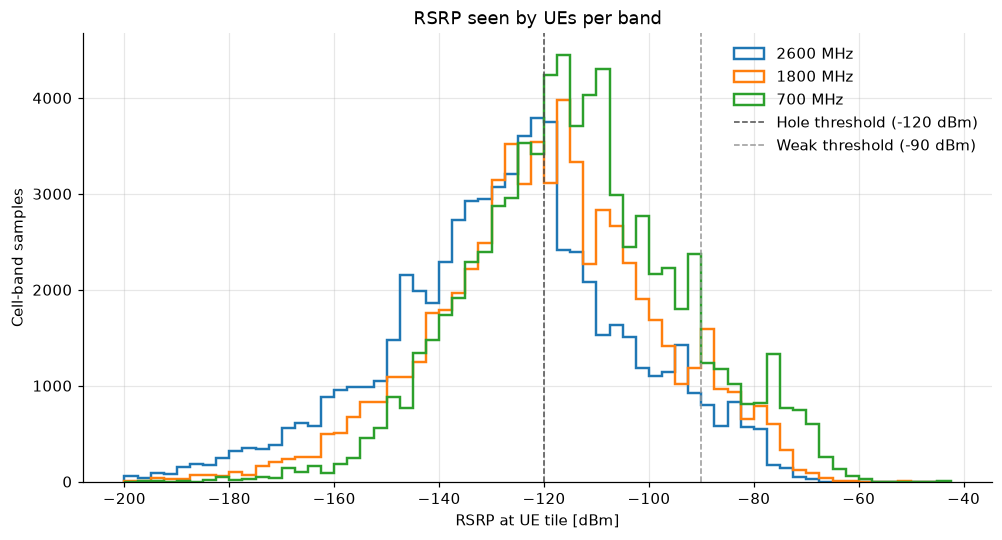

,Property,Value
0,UE rows,10066.0000
1,UEs with no path to any cell [%],2.1061
2,UEs at or below -120 dBm (incl. no path) [%],7.1031
3,Cell-band pairs per UE,36.0000


In [12]:
ue_rsrp = max_rsrp(rsrp)[ue["tile_row"].to_numpy(), ue["tile_col"].to_numpy()]
hole_dbm, weak_dbm = float(cfg.kpi.hole_dbm), float(cfg.kpi.weak_dbm)

figure, axis = plt.subplots(figsize=(9.0, 4.8), constrained_layout=True)
edges = np.arange(-200.0, -40.0, 2.5)
for index, band in enumerate(bands):
    values = rsrp[index][:, ue["tile_row"].to_numpy(), ue["tile_col"].to_numpy()].ravel()
    axis.hist(values[np.isfinite(values)], bins=edges, histtype="step", lw=1.6, label=label(band))
axis.axvline(hole_dbm, color="0.3", ls="--", lw=1, label=f"Hole threshold ({hole_dbm:g} dBm)")
axis.axvline(weak_dbm, color="0.6", ls="--", lw=1, label=f"Weak threshold ({weak_dbm:g} dBm)")
axis.set(
    xlabel="RSRP at UE tile [dBm]", ylabel="Cell-band samples", title="RSRP seen by UEs per band"
)
axis.legend()
save_fig(figure, "ue_rsrp_distribution")
plt.show()

display(
    property_table(
        {
            "UE rows": len(ue),
            "UEs with no path to any cell [%]": 100.0 * (~np.isfinite(ue_rsrp)).mean(),
            f"UEs at or below {hole_dbm:g} dBm (incl. no path) [%]": 100.0
            * (~(ue_rsrp > hole_dbm)).mean(),
            "Cell-band pairs per UE": rsrp.shape[0] * rsrp.shape[1],
        },
        "ue_measurement_summary",
    )
)

## 6. Cell Selection Model

`src/kpi/capacity.py` assigns every UE, interval by interval, in a seeded random order. Each UE ranks
its cell-bands: those at or above `kpi.capacity.rsrp_threshold_dbm` by band preference
(`kpi.capacity.band_preference`) then RSRP, followed by the rest by RSRP. Layers at or below
`kpi.hole_dbm` are never candidates. The UE takes the first cell-band still at or under
`max_admission_utilisation` of its `max_prb` with room for the PRBs its throughput needs
(Shannon rate at the tile's SINR). Before capacity, the rule reduces to

$$
s(g) = \underset{(i,b)\,:\,R_{i,b}(g) \ge T_{\mathrm{thr}}}{\arg\min}\;\bigl(\mathrm{rank}(b),\,-R_{i,b}(g)\bigr).
$$

Hysteresis, cell-selection offsets and mobility state are not modelled.

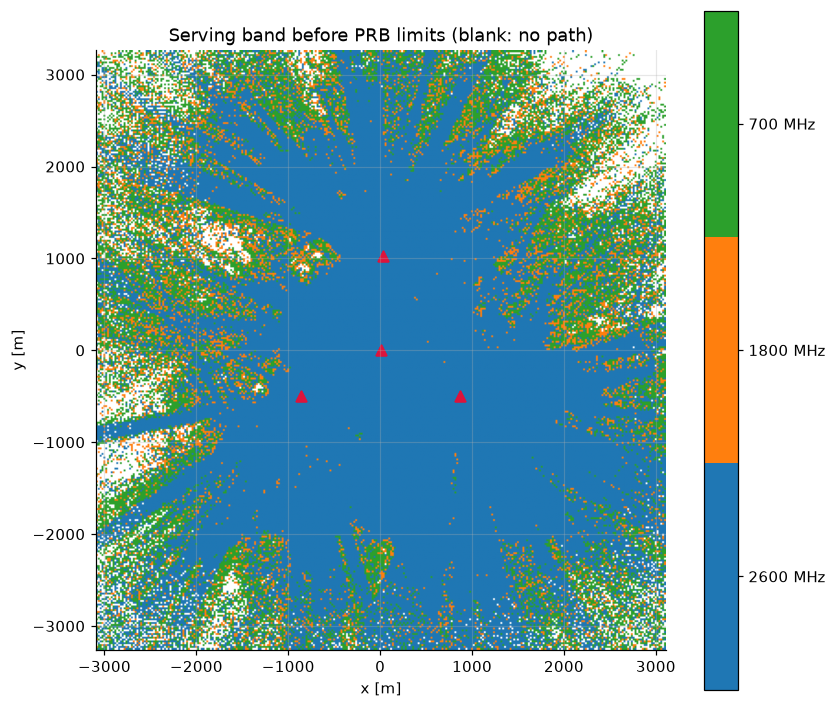

,Serving band,Share of UEs
0,2600 MHz,0.4604
1,1800 MHz,0.1147
2,700 MHz,0.0841
3,Not served,0.3408


In [13]:
from src.evaluation import compare
from src.kpi import capacity

spec = capacity.CapacitySpec.from_config(cfg, bands, len(cells))
serving = maps.serving_band(rsrp, spec.band_rank, spec.rsrp_threshold_dbm)
figure, axis = plt.subplots(figsize=(7.5, 6.5), constrained_layout=True)
colours = plt.get_cmap("tab10")
image = axis.imshow(
    np.ma.masked_less(serving, 0),
    origin="lower",
    extent=maps.extent_of(radio_map),
    cmap=plt.matplotlib.colors.ListedColormap([colours(i) for i in range(len(bands))]),
    vmin=-0.5,
    vmax=len(bands) - 0.5,
)
bar = figure.colorbar(image, ax=axis, ticks=range(len(bands)))
bar.ax.set_yticklabels([label(band) for band in bands])
axis.scatter(nodes["x"], nodes["y"], marker="^", s=45, color="crimson")
axis.set(xlabel="x [m]", ylabel="y [m]", title="Serving band before PRB limits (blank: no path)")
save_fig(figure, "serving_band_map")
plt.show()

served = capacity.serve_intervals(rsrp, sinr, bands, ue, cfg)
service = compare.service_summary(served, bands)
serving_mix = pd.DataFrame(
    [{"Serving band": label(band), "Share of UEs": service[f"share_{band}"]} for band in bands]
    + [{"Serving band": "Not served", "Share of UEs": service["not_served_share"]}]
)
save_table(serving_mix, "serving_band_mix")
serving_mix

## 7. Decision Variables and Constraints

The optimization variable is the absolute electrical tilt of every cell-band pair,
$\boldsymbol{\Theta} = \{\theta_{i,b}\}$, bounded per pair (`src/optim/space.py`, `TiltSpace`):

$$
\theta^{\min}_{i,b} \le \theta_{i,b} \le \theta^{\max}_{i,b}.
$$

The baseline $\theta^{(0)}_{i,b}$ is the committed `baseline_deg`. The current implementation has
**no** maximum-change constraint $|\theta - \theta^{(0)}| \le \Delta\theta^{\max}$ and **no** step
grid $\delta\theta$; the box is the only constraint.

In [14]:
from src.optim.space import TiltSpace

space = TiltSpace.from_config(cfg)
decision = pd.DataFrame(
    {
        "cell": [c for c, _ in space.pairs],
        "band": [b for _, b in space.pairs],
        "baseline": space.baseline,
        "lower": space.lower,
        "upper": space.upper,
    }
)
decision_summary = (
    decision.groupby("band", sort=False)
    .agg(
        pairs=("cell", "size"),
        baseline=("baseline", "median"),
        lower=("lower", "min"),
        upper=("upper", "max"),
    )
    .reset_index()
    .rename(
        columns={
            "band": "Band",
            "pairs": "Cell-band pairs",
            "baseline": "Baseline tilt [°]",
            "lower": "Minimum tilt [°]",
            "upper": "Maximum tilt [°]",
        }
    )
)
decision_summary["Band"] = decision_summary["Band"].map(label)
save_table(decision_summary, "decision_variables")
print(f"{space.n_dim} decision variables")
decision_summary

36 decision variables


,Band,Cell-band pairs,Baseline tilt [°],Minimum tilt [°],Maximum tilt [°]
0,2600 MHz,12,12.0,0.0,15.0
1,1800 MHz,12,12.0,0.0,15.0
2,700 MHz,12,12.0,0.0,15.0


## 8. Evaluation Metrics

Grid KPIs weight every tile equally ($w_g = 1$ over the whole grid $G$); only the served ratio and
$J_{\mathrm{load}}$ count UEs. $R_{\mathrm{serv}}(g)$ is the strongest RSRP over all cell-bands,
$-\infty$ where no path exists. Thresholds come from `configs/kpi.yaml`.

**8.1 Coverage hole rate** (minimised)
$$
\mathrm{HoleRate} = \frac{1}{|G|}\sum_g \mathbb{1}\bigl[R_{\mathrm{serv}}(g) \le T_{\mathrm{hole}}\bigr]
$$

**8.2 Weak coverage rate** (minimised)
$$
\mathrm{WeakRate} = \frac{1}{|G|}\sum_g \mathbb{1}\bigl[T_{\mathrm{hole}} < R_{\mathrm{serv}}(g) \le T_{\mathrm{weak}}\bigr]
$$

**8.3 Co-band overlap rate** (minimised). On each band $b$ with strongest transmitter $s_b(g)$ above
$T_{\mathrm{hole}}$, a neighbour $j$ overlaps when $R_j(g) > T_{\mathrm{hole}}$ and
$R_{s_b}(g) - R_j(g) \le \Delta_R$. Summed over bands this gives $m_g$ (`overlap_neighbors`), and
$$
\mathrm{OverlapRate} = \frac{1}{|G|}\sum_g \mathbb{1}[m_g > 0].
$$

**8.4 Served UE ratio** (maximised): the share of all UE rows admitted to a cell-band by the serving
rule of Section 6. UEs with no path, or blocked by PRB limits, are not served.

**8.5 Cell-edge RSRP**: the 5th percentile of $R_{\mathrm{serv}}$ over covered tiles only
(3GPP TR 36.814 Annex A.2.1.4), read beside the hole rate.

**8.6 Objective terms** (ADR 0006)
$$
J_{\mathrm{radio}} = \frac{1}{|G|}\sum_g \sigma\!\left(\frac{R_{\mathrm{serv}}(g) - T_{\mathrm{hole}}}{\tau_R}\right) e^{-\beta m_g},
\qquad
J_{\mathrm{load}} = 1 - \frac{\mathrm{CVaR}_\alpha\bigl([\rho - \rho_0]_+\bigr)}{1-\rho_0},
$$
with $\rho$ the admitted PRB utilisation of one cell-band in one interval.
The template's mean-overlap-neighbour count and band priority score are not project KPIs; the mean of
$m_g$ is shown below for reference only.

In [15]:
from src.kpi.overlap import overlap_neighbors
from src.optim import objective

kpis = objective.evaluate_kpis(rsrp, sinr, bands, ue, cfg)
neighbours = overlap_neighbors(rsrp, cfg)
baseline_kpis = pd.DataFrame(
    [
        *({"Measure": label(name), "Baseline": value} for name, value in kpis.as_dict().items()),
        {"Measure": label("score"), "Baseline": float(objective.score([kpis], cfg)[0])},
        {
            "Measure": "Mean co-band overlapping neighbours (reference)",
            "Baseline": float(neighbours.mean()),
        },
    ]
)
save_table(baseline_kpis, "baseline_kpis")
baseline_kpis

,Measure,Baseline
0,Coverage hole rate,0.1860
1,Co-band overlap rate,0.2819
2,Served UE ratio,0.6592
3,Weak coverage rate,0.4307
4,Cell-edge RSRP,-113.1969
5,Radio utility J_radio,0.5437
6,Load utility J_load,0.7949
7,Objective J,0.6574
8,Mean co-band overlapping neighbours (reference),0.7011


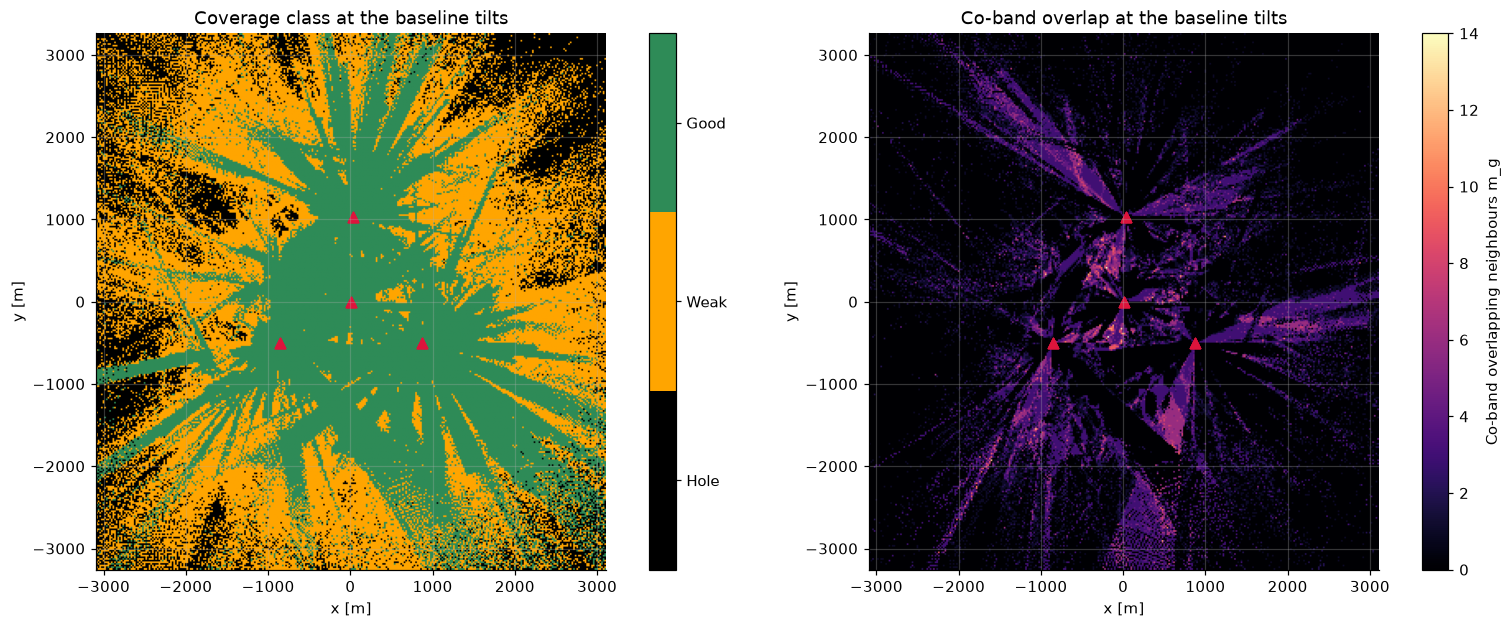

,coverage,tiles,tile_share,prb,demand_share
0,hole,18794,0.1860,0.0000e+00,0.0000
1,weak,43530,0.4307,1.5458e+06,0.9051
2,good,38736,0.3833,1.6204e+05,0.0949


In [16]:
extent = maps.extent_of(radio_map)
figure, axes = plt.subplots(1, 2, figsize=(14.0, 5.6), constrained_layout=True)

classes = maps.coverage_class(rsrp, cfg)
image = axes[0].imshow(
    classes,
    origin="lower",
    extent=extent,
    cmap=plt.matplotlib.colors.ListedColormap(["black", "orange", "seagreen"]),
    vmin=-0.5,
    vmax=2.5,
)
bar = figure.colorbar(image, ax=axes[0], ticks=range(3))
bar.ax.set_yticklabels([name.capitalize() for name in maps.COVERAGE_CLASSES])
axes[0].set_title("Coverage class at the baseline tilts")

image = axes[1].imshow(neighbours, origin="lower", extent=extent, cmap="magma")
figure.colorbar(image, ax=axes[1], label="Co-band overlapping neighbours m_g")
axes[1].set_title("Co-band overlap at the baseline tilts")
for axis in axes:
    axis.scatter(nodes["x"], nodes["y"], marker="^", s=45, color="crimson")
    axis.set(xlabel="x [m]", ylabel="y [m]")
save_fig(figure, "coverage_and_overlap_maps")
plt.show()

area_vs_demand = maps.coverage_table(rsrp, capacity.demand_prb(rsrp, sinr, bands, ue, cfg), cfg)
save_table(area_vs_demand, "coverage_by_area_and_demand")
area_vs_demand

## 9. Simulation Workflow

| # | Stage | Code |
|---|---|---|
| 1 | Load the 3D scene, cell table and antenna arrays | `src/simulation/scene.py`, `transmitter.py`, `radio.configure_arrays` |
| 2 | Raster open ground; draw hotspots, traffic and UE positions | `src/simulation/scenario.py` (`task simulation:scenario`) |
| 3 | Place cells at their per-band tilts and ray-trace every band | `src/simulation/radio.py` (`task simulation:radio`) |
| 4 | Convert path gain to RSRP and SINR per tile | `src/simulation/radio.py` |
| 5 | Verify artifacts; write typed UE and cell tables | `src/data/build.py` (`task preprocess`, notebook 02) |
| 6 | Serve UEs; measure KPIs and objective terms | `src/kpi/`, `src/optim/objective.py` |
| 7 | Propose tilts, re-trace, re-measure until the budget is spent | `src/optim/run.py` (notebooks 03a, 03b) |
| 8 | Compare the best configurations with the baseline | `src/evaluation/run.py` (notebook 04) |

Stages 1–6 run in this notebook.

## 10. Experimental Configurations

### 10.1 Baseline

| Property | Description |
|---|---|
| Tilt configuration | Committed `baseline_deg` of every cell-band pair (Section 3.2) |
| Azimuths | Node fans rotated by `transmitters.layout.azimuth_offset_deg` |
| UE distribution | The fixed scenario drawn in Section 3.3, every UE kept |
| Propagation settings | `simulation.radio_map`, identical for every configuration |
| Optimization | None |

## 11. Result Summary

The baseline column is the KPI table of Section 8. The optimized columns and their changes are
produced by notebook 04 from the runs of notebooks 03a and 03b; optimization runs from before this
configuration change are not comparable and must be rerun.

In [17]:
baseline_kpis

,Measure,Baseline
0,Coverage hole rate,0.1860
1,Co-band overlap rate,0.2819
2,Served UE ratio,0.6592
3,Weak coverage rate,0.4307
4,Cell-edge RSRP,-113.1969
5,Radio utility J_radio,0.5437
6,Load utility J_load,0.7949
7,Objective J,0.6574
8,Mean co-band overlapping neighbours (reference),0.7011


## 12. Key Findings

Baseline: every cell-band at 12° tilt, fans rotated by -45°.

* **Coverage.** 18.6% of grid tiles are coverage holes and 43.1% are weak, leaving 38.3% with good
  coverage. The weak class matters most: it holds 90.5% of the PRB demand, while holes hold none, because
  the hotspots stand near the masts.
* **Band reach.** 700 MHz reaches the most tiles (85.4%, median -92 dBm). 2600 MHz reaches 82.0% at a
  median of -103 dBm. At a uniform 12° tilt the high bands are the weaker coverage layer.
* **Co-band overlap.** 28.2% of tiles have at least one co-band neighbour within 6 dB, with 0.70
  overlapping neighbours per tile on average.
* **Preferred-band use.** Band preference puts 46.0% of UEs on 2600 MHz, 11.5% on 1800 MHz and 8.4% on 700 MHz.
* **Service.** The served ratio is 65.9% over all UEs. 2.1% of UEs have no path to any cell and 7.1% are
  at or below the hole threshold. The remaining unserved share (about 27 points) is blocked by PRB limits
  under the placeholder capacity settings, so capacity, not coverage, is what limits the served ratio.
* **Objective.** J_radio = 0.544 and J_load = 0.795, giving J = 0.657. The radio term has more room to
  improve than the load term.
* **Trade-offs and per-cell changes** need an optimized configuration. They are reported by notebook 04 once
  03a and 03b have been rerun on this configuration.

## 13. Assumptions and Limitations

* The 3D scene and its frequency-static materials approximate the real environment.
* Antenna positions come from the layout generator and azimuths from a fixed offset, not a surveyed site plan.
* UE positions are independent per interval; there is no mobility or handover.
* RSRP is the clean ray-traced value at the tile centre; no measurement noise, report censoring or
  position error is modelled.
* SINR assumes full-load interference; throughput uses the Shannon rate without MCS tables.
* Capacity settings in `configs/kpi.yaml` are placeholders.
* Grid KPIs count area, including area without users.
* Simulation improvements must be validated with field measurements before operational deployment.

## 14. Conclusion

This notebook builds a reproducible scenario for multi-band tilt coordination: a fixed city, layout and
UE population, a ray-traced radio map at the baseline tilts, and the KPIs and objective terms every
optimizer is measured by. It supports engineering analysis and candidate selection; it does not replace
field validation or controlled network trials.